# Discovering novel / unknown cell types

A cell type the reference has **never seen** doesn't show up as a few scattered
uncertain cells — it shows up as a **coherent group the reference can't confidently
explain**. `detect_novel_celltypes` looks for exactly that: clusters that are both
large enough to be a real population *and* predominantly low-confidence. This is
*cluster-level* rejection, distinct from the per-cell `min_prob` abstain (which flags
individual uncertain cells).

**This notebook validates it on a real discovery.** In the Krasnow *et al.* (2020)
human lung atlas we train a reference but **withhold the pulmonary ionocyte** — itself
a landmark 2018 novel-cell-type discovery (Montoro/Plasschaert) — then ask the workflow
to find what's missing. It should flag the withheld ionocytes and nothing else.


In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, scanpy as sc
import matplotlib.pyplot as plt
import actinn_jax as aj

QUERY = '/Users/iandriver/Downloads/krasnow_lung_atlas_10x.h5ad'  # <- your .h5ad (raw counts)
LABEL_COL = 'free_annotation'   # the atlas's cell-type annotation
HOLDOUT   = 'Ionocyte'          # withhold this type so it becomes 'novel'

adata = sc.read_h5ad(QUERY)
adata.obs['label'] = adata.obs[LABEL_COL].astype(str)
n_hold = int((adata.obs['label'] == HOLDOUT).sum())
print(f'{adata.n_obs:,} cells, {adata.obs.label.nunique()} annotated types')
print(f'{HOLDOUT}: {n_hold} cells  (rare — a good test of the min_cells floor)')

65,662 cells, 57 annotated types
Ionocyte: 22 cells  (rare — a good test of the min_cells floor)


## 1. Build a reference that has never seen the ionocyte

Leave-one-out: we train on every type **except** the ionocyte, so from the reference's
point of view the ionocyte is a genuinely novel population.


In [2]:
train = adata[adata.obs['label'] != HOLDOUT].copy()
model = aj.train_reference(train, train_label_name='label',
                           max_cells_per_label=300, print_cost=False)
print(f'reference trained on {train.obs.label.nunique()} types ({HOLDOUT} withheld)')

Cell types in training set: {'Adventitial Fibroblast': 0, 'Airway Smooth Muscle': 1, 'Alveolar Epithelial Type 1': 2, 'Alveolar Epithelial Type 2': 3, 'Alveolar Fibroblast': 4, 'Artery': 5, 'B': 6, 'Basal': 7, 'Basophil/Mast 1': 8, 'Basophil/Mast 2': 9, 'Bronchial Vessel 1': 10, 'Bronchial Vessel 2': 11, 'CD4+ Memory/Effector T': 12, 'CD4+ Naive T': 13, 'CD8+ Memory/Effector T': 14, 'CD8+ Naive T': 15, 'Capillary': 16, 'Capillary Aerocyte': 17, 'Capillary Intermediate 1': 18, 'Capillary Intermediate 2': 19, 'Ciliated': 20, 'Classical Monocyte': 21, 'Club': 22, 'Differentiating Basal': 23, 'EREG+ Dendritic': 24, 'Fibromyocyte': 25, 'Goblet': 26, 'IGSF21+ Dendritic': 27, 'Intermediate Monocyte': 28, 'Lipofibroblast': 29, 'Lymphatic': 30, 'Macrophage': 31, 'Mesothelial': 32, 'Mucous': 33, 'Myeloid Dendritic Type 1': 34, 'Myeloid Dendritic Type 2': 35, 'Myofibroblast': 36, 'Natural Killer': 37, 'Natural Killer T': 38, 'Neuroendocrine': 39, 'Nonclassical Monocyte': 40, 'OLR1+ Classical Mono

reference trained on 56 types (Ionocyte withheld)


## 2. Detect novel populations

Pass your own clustering via `cluster_key` (here we use the atlas's annotation; in
practice use your Leiden/Louvain clusters, or omit it to auto-cluster). `min_cells` is
the tunable **size floor** — the default (10) separates a real population from noise.
`evidence` reports, per cluster, how low-confidence it is and what the reference *would*
have mislabeled it.


In [3]:
evidence, markers = aj.detect_novel_celltypes(
    model, adata, cluster_key=LABEL_COL, min_prob=0.5, min_cells=10)

print('flagged as novel:')
cols = ['cluster','n_cells','frac_low_conf','median_conf','nearest_label']
display(evidence[evidence.novel][cols].reset_index(drop=True))
print(f"\n{HOLDOUT} was flagged: {HOLDOUT in set(evidence[evidence.novel].cluster)}")
print('most-suspect clusters overall:')
display(evidence[cols].head(6))

flagged as novel:


,cluster,n_cells,frac_low_conf,median_conf,nearest_label
0,Ionocyte,22,0.864,0.303,B



Ionocyte was flagged: True
most-suspect clusters overall:


,cluster,n_cells,frac_low_conf,median_conf,nearest_label
0,Ionocyte,22,0.864,0.303,B
1,CD8+ Naive T,2042,0.177,0.768,CD8+ Naive T
2,Capillary,7391,0.103,0.890,Capillary
3,CD8+ Memory/Effector T,1190,0.101,0.887,CD8+ Memory/Effector T
4,CD4+ Memory/Effector T,3013,0.077,0.920,CD4+ Memory/Effector T
5,Classical Monocyte,2077,0.052,0.983,Classical Monocyte


## 3. What is it? — marker genes

For each flagged cluster the workflow returns its top genes (mean expression in the
cluster vs. the rest of the dataset), translated here to symbols.


In [4]:
symcol = next((c for c in ('feature_name','gene_name','gene_symbol','symbol')
               if c in adata.var.columns), None)
sym = dict(zip(adata.var_names.astype(str), adata.var[symcol].astype(str))) if symcol else {}

for cl, name in [(r['cluster'], f'novel_{i+1}')
                 for i, r in enumerate(evidence[evidence.novel].to_dict('records'))]:
    genes = [sym.get(g, g) for g in markers[name]]
    print(f"{name}  (was '{cl}')  markers: {genes}")
print('\nASCL3 is the ionocyte master transcription factor; ATP6V0B is the V-ATPase\n'
      'subunit ionocytes are literally named for — the workflow recovered both.')

novel_1  (was 'Ionocyte')  markers: ['ASCL3', 'MGST1', 'CD24', 'KRT8', 'CD9', 'EPCAM', 'KRT18', 'SEC11C', 'KRT7', 'ATP6V0B']

ASCL3 is the ionocyte master transcription factor; ATP6V0B is the V-ATPase
subunit ionocytes are literally named for — the workflow recovered both.


## 4. The `min_cells` knob

`min_cells` is the minimum population size to call something novel. The ionocyte has
only 22 cells, so raising the floor above it drops the flag — lower it to hunt rarer
candidates, raise it to be stricter.


In [5]:
for mc in [5, 10, 22, 25, 30]:
    ev, _ = aj.detect_novel_celltypes(model, adata, cluster_key=LABEL_COL, min_cells=mc)
    flagged = sorted(ev[ev.novel].cluster)
    print(f'min_cells={mc:>2}: {len(flagged)} flagged  {flagged}')

min_cells= 5: 1 flagged  ['Ionocyte']


min_cells=10: 1 flagged  ['Ionocyte']


min_cells=22: 1 flagged  ['Ionocyte']


min_cells=25: 0 flagged  []


min_cells=30: 0 flagged  []


## 5. Highlight the novel cells

`detect_novel_celltypes` writes `obs['novel']` (the `novel_k` label on flagged cells)
and `obs['novel_confidence']` (each cell's best reference probability). On the atlas's
t-SNE, the flagged population sits exactly where the reference is least confident.


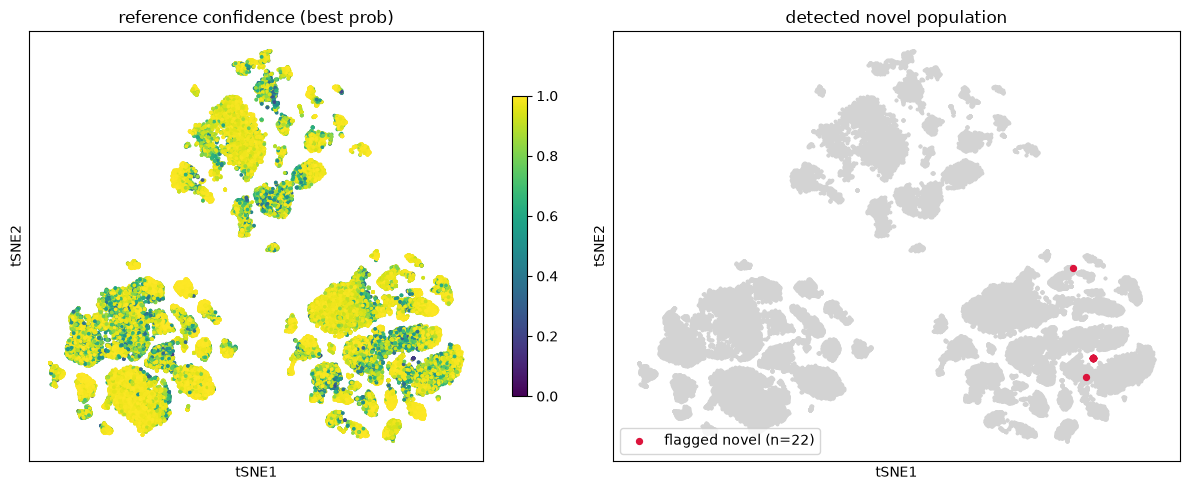

In [6]:
# The min_cells sweep above overwrote obs['novel']; recompute at our chosen floor.
aj.detect_novel_celltypes(model, adata, cluster_key=LABEL_COL, min_prob=0.5, min_cells=10)

xy = adata.obsm['X_tSNE']
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

s = ax[0].scatter(xy[:,0], xy[:,1], c=adata.obs['novel_confidence'], s=3,
                  cmap='viridis', vmin=0, vmax=1, rasterized=True)
ax[0].set_title('reference confidence (best prob)'); fig.colorbar(s, ax=ax[0], shrink=.7)

is_novel = (adata.obs['novel'] != '').values
ax[1].scatter(xy[~is_novel,0], xy[~is_novel,1], c='lightgrey', s=3, rasterized=True)
ax[1].scatter(xy[is_novel,0],  xy[is_novel,1],  c='crimson', s=18,
              label=f'flagged novel (n={int(is_novel.sum())})')
ax[1].set_title('detected novel population'); ax[1].legend(loc='lower left')
for a in ax: a.set_xticks([]); a.set_yticks([]); a.set_xlabel('tSNE1'); a.set_ylabel('tSNE2')
plt.tight_layout(); plt.show()

## Using this on your own data

1. Annotate with a reference (`aj.bundled_reference(...)` or your own).
2. Cluster your query (Leiden/Louvain) and pass it as `cluster_key`, **or** omit
   `cluster_key` to auto-cluster (needs `leidenalg`/`igraph`).
3. `evidence[evidence.novel]` lists candidate novel populations; `markers` gives their
   top genes; `obs['novel']` highlights the cells.
4. Lower `min_cells` (e.g. 5) to surface rarer candidates; raise it to be conservative.

A flagged cluster isn't proof of a new cell type — it's a **prioritized lead**: a
coherent population your reference can't explain, with markers to characterize it.
